# Analyzing Results
In this notebook, we will
- analyze the `avg_time` for the different run experiments.
- calculate the speedup for each `arr_size` & `arr_distribution` combination.

**Sections**

* [1.0 Setup](#1.0-Setup)
* [2.0 Analyzing the Implementation Behavior](#2.0-Analyzing-the-Implementation-Behavior)
* [3.0 Anayzing SpeedUp](#3.0-Anayzing-SpeedUp)

---
---

## 1.0 Setup

**1.1 Importing Packages & Data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
experiments_data = pd.read_csv("running_results.csv")
experiments_data.head()

,implementation,n_repeats,array_size,array_distribution,n_threads,blocksize,avg_time
0,serial,5,1048576,uniform,0,0,0.155119
1,serial,5,1048576,gaussian,0,0,0.136650
2,serial,5,1048576,nearly_sorted,0,0,0.084480
3,serial,5,1048576,reversed,0,0,0.077724
4,serial,5,4194304,uniform,0,0,0.645236


---
---

## 2.0 Analyzing the Implementation Behavior
- how do `avg_time` changes by using different parameters `[threads | blocksizes | array distributions | array sizes]`

**2.1 Serial Experiments**

In [4]:
serial_exp = experiments_data[experiments_data["implementation"] == "serial"]
serial_exp.shape

(16, 7)

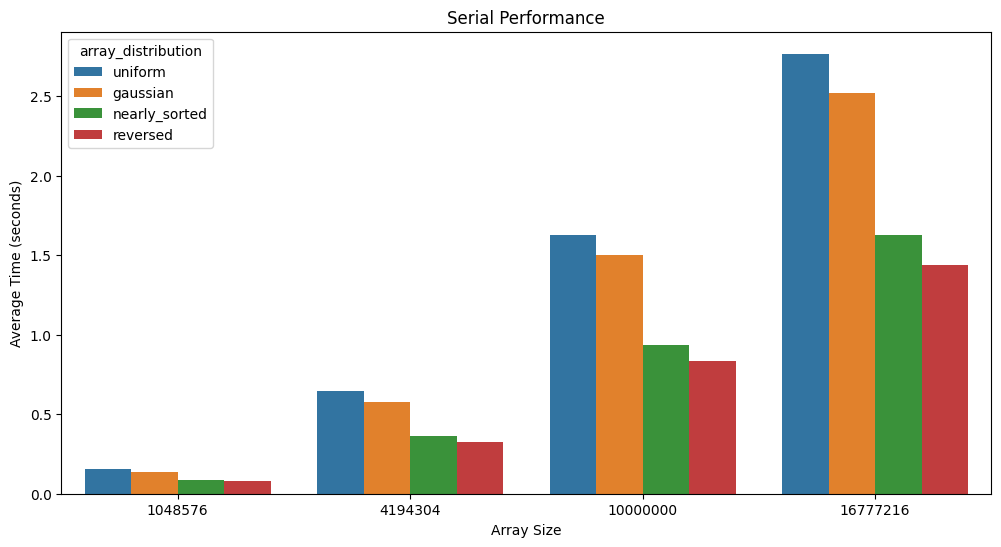

In [6]:
plt.figure(figsize = (12, 6))
sns.barplot(data = serial_exp, x = "array_size", y = 'avg_time', hue = "array_distribution")
    
plt.title(f'Serial Performance')
plt.ylabel('Average Time (seconds)')
plt.xlabel(f'Array Size')
    
    
plt.savefig(f"results_figures/serial_performance.png")
plt.show()

**2.2 OpenMP Experiments**

In [7]:
openmp_exp = experiments_data[experiments_data["implementation"] == "omp"]
openmp_exp.shape

(80, 7)

In [8]:
openmp_exp.head()

,implementation,n_repeats,array_size,array_distribution,n_threads,blocksize,avg_time
16,omp,5,1048576,uniform,1,0,0.151243
17,omp,5,1048576,uniform,2,0,0.080367
18,omp,5,1048576,uniform,4,0,0.059887
19,omp,5,1048576,uniform,8,0,0.039530
20,omp,5,1048576,uniform,16,0,0.033329


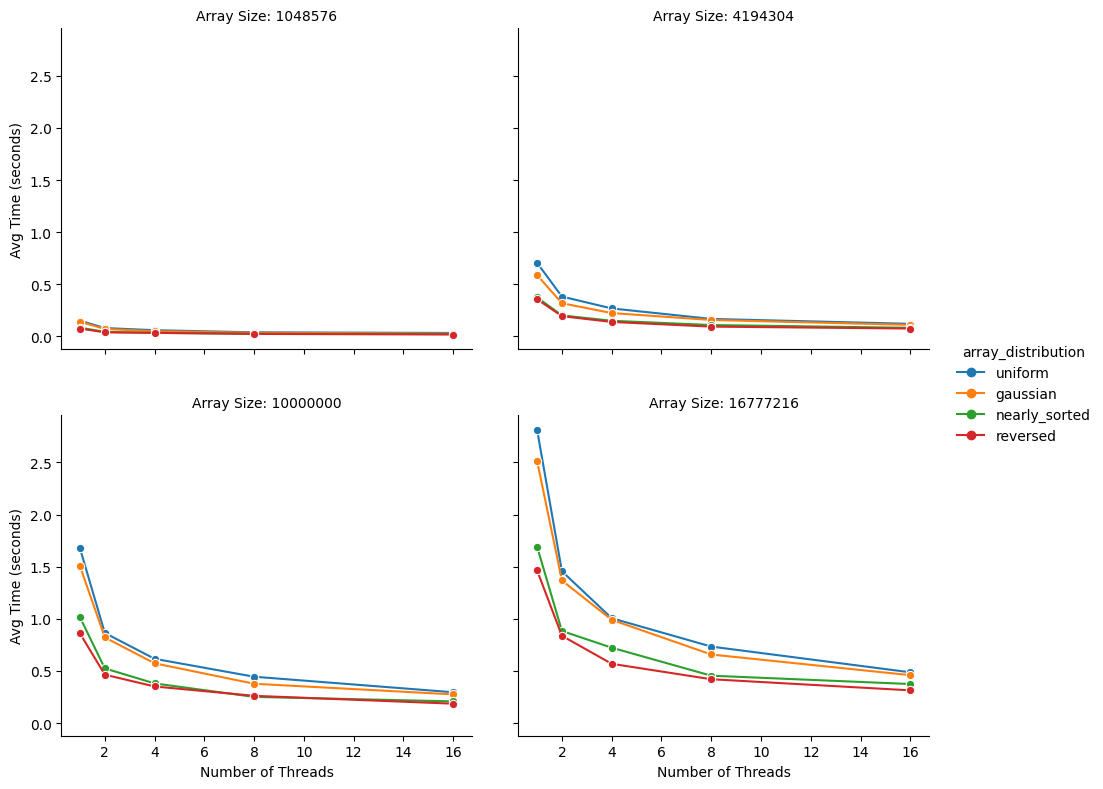

In [9]:
g = sns.relplot(
    data = openmp_exp, 
    x = "n_threads", 
    y = "avg_time", 
    hue = "array_distribution", 
    col = "array_size", 
    kind = "line", 
    marker = "o",
    col_wrap = 2, 
    height = 4, 
    aspect = 1.2
)


g.set_axis_labels("Number of Threads", "Avg Time (seconds)")
g.set_titles("Array Size: {col_name}")
g.tight_layout(h_pad = 3, w_pad = 3)

plt.savefig("results_figures/omp_performance.png", dpi = 300)
plt.show()

**2.3 CUDA Experiments**

In [10]:
cuda_exp = experiments_data[experiments_data["implementation"] == "cuda"]
cuda_exp.shape

(48, 7)

In [11]:
cuda_exp.head()

,implementation,n_repeats,array_size,array_distribution,n_threads,blocksize,avg_time
96,cuda,5,1048576,uniform,0,128,0.006079
97,cuda,5,1048576,uniform,0,256,0.005461
98,cuda,5,1048576,uniform,0,512,0.005564
99,cuda,5,1048576,gaussian,0,128,0.005639
100,cuda,5,1048576,gaussian,0,256,0.005212


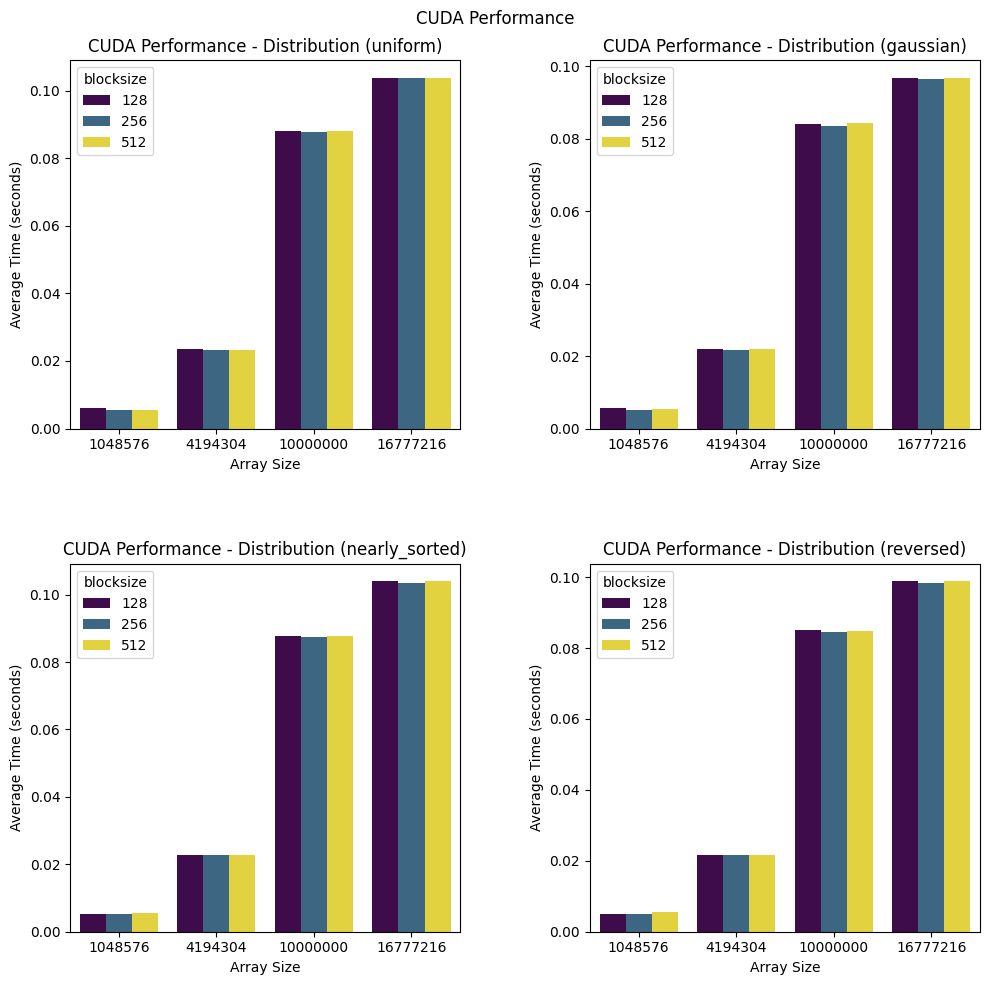

In [12]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))

dists = ["uniform", "gaussian", "nearly_sorted", "reversed"]
for ax, d in zip(axes.flat, dists):
    sns.barplot(data = cuda_exp[cuda_exp["array_distribution"] == d], x = "array_size", y = 'avg_time', hue = "blocksize", ax = ax, palette = "viridis")

    ax.set_title(f'CUDA Performance - Distribution ({d})')
    ax.set_ylabel('Average Time (seconds)')
    ax.set_xlabel('Array Size')

fig.suptitle('CUDA Performance')
plt.tight_layout(h_pad = 5, w_pad = 5)

plt.savefig(f"results_figures/cuda_performance.png")
plt.show()

---
---

## 3.0 Anayzing SpeedUp

In [13]:
experiments_data.head()

,implementation,n_repeats,array_size,array_distribution,n_threads,blocksize,avg_time
0,serial,5,1048576,uniform,0,0,0.155119
1,serial,5,1048576,gaussian,0,0,0.136650
2,serial,5,1048576,nearly_sorted,0,0,0.084480
3,serial,5,1048576,reversed,0,0,0.077724
4,serial,5,4194304,uniform,0,0,0.645236


**3.1 Calculating SpeedUp**

In [14]:
serial_baseline = experiments_data[experiments_data['implementation'] == 'serial'].set_index(['array_size', 'array_distribution'])['avg_time']
serial_baseline.head()

array_size  array_distribution
1048576     uniform               0.155119
            gaussian              0.136650
            nearly_sorted         0.084480
            reversed              0.077724
4194304     uniform               0.645236
Name: avg_time, dtype: float64

In [15]:
def calc_speedup(row):
    """
    Args:
        row: a row in a pandas dataframe
    """
    time_serial = serial_baseline.loc[(row['array_size'], row['array_distribution'])]
    time_parallel = row['avg_time']

    return time_serial / time_parallel

In [16]:
experiments_data['speedup'] = experiments_data.apply(calc_speedup, axis = 1)
experiments_data.head(30)

,implementation,n_repeats,array_size,array_distribution,n_threads,blocksize,avg_time,speedup
0,serial,5,1048576,uniform,0,0,0.155119,1.000000
1,serial,5,1048576,gaussian,0,0,0.136650,1.000000
2,serial,5,1048576,nearly_sorted,0,0,0.084480,1.000000
3,serial,5,1048576,reversed,0,0,0.077724,1.000000
4,serial,5,4194304,uniform,0,0,0.645236,1.000000
5,serial,5,4194304,gaussian,0,0,0.578529,1.000000
6,serial,5,4194304,nearly_sorted,0,0,0.361103,1.000000
7,serial,5,4194304,reversed,0,0,0.325140,1.000000
8,serial,5,16777216,uniform,0,0,2.767556,1.000000
9,serial,5,16777216,gaussian,0,0,2.523500,1.000000


**3.2 OpenMP SpeedUp**

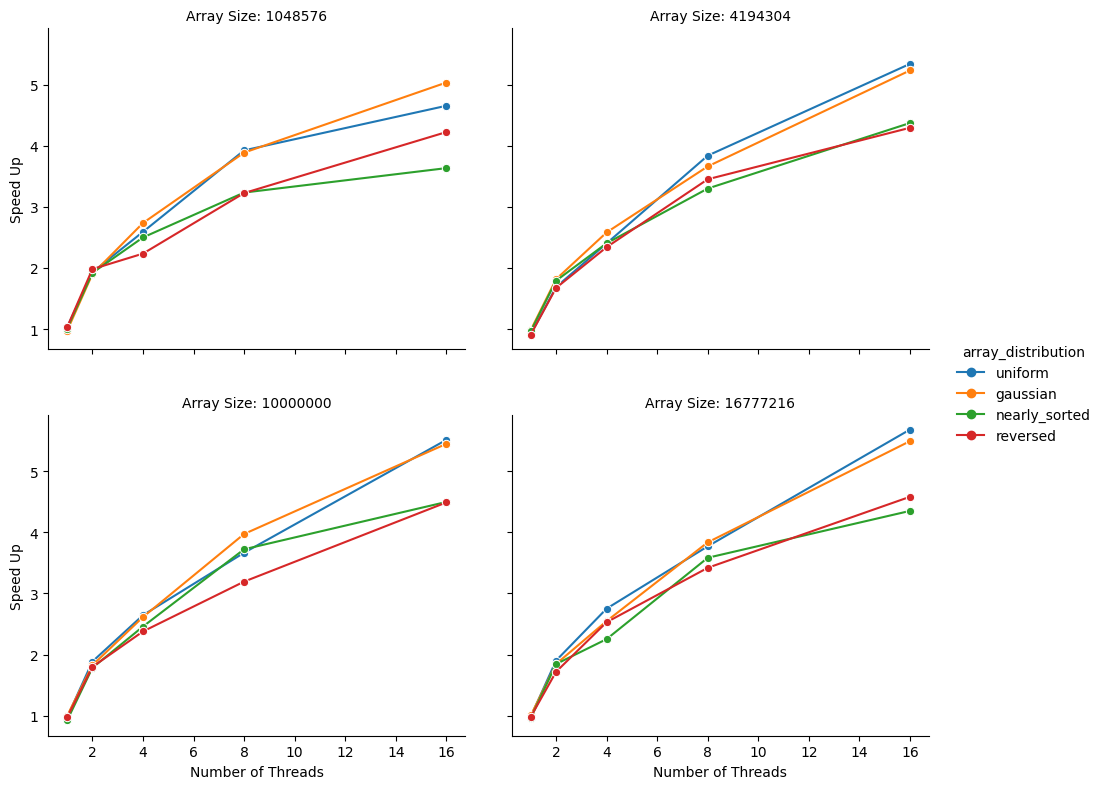

In [17]:
openmp_exp = experiments_data[experiments_data['implementation'] == 'omp']
g = sns.relplot(
    data = openmp_exp, 
    x = "n_threads", 
    y = "speedup", 
    hue = "array_distribution", 
    col = "array_size", 
    kind = "line", 
    marker = "o",
    col_wrap = 2, 
    height = 4, 
    aspect = 1.2
)


g.set_axis_labels("Number of Threads", "Speed Up")
g.set_titles("Array Size: {col_name}")
g.tight_layout(h_pad = 3, w_pad = 3)

plt.savefig("results_figures/omp_speedup.png", dpi = 300)
plt.show()

**3.3 CUDA SpeedUp**

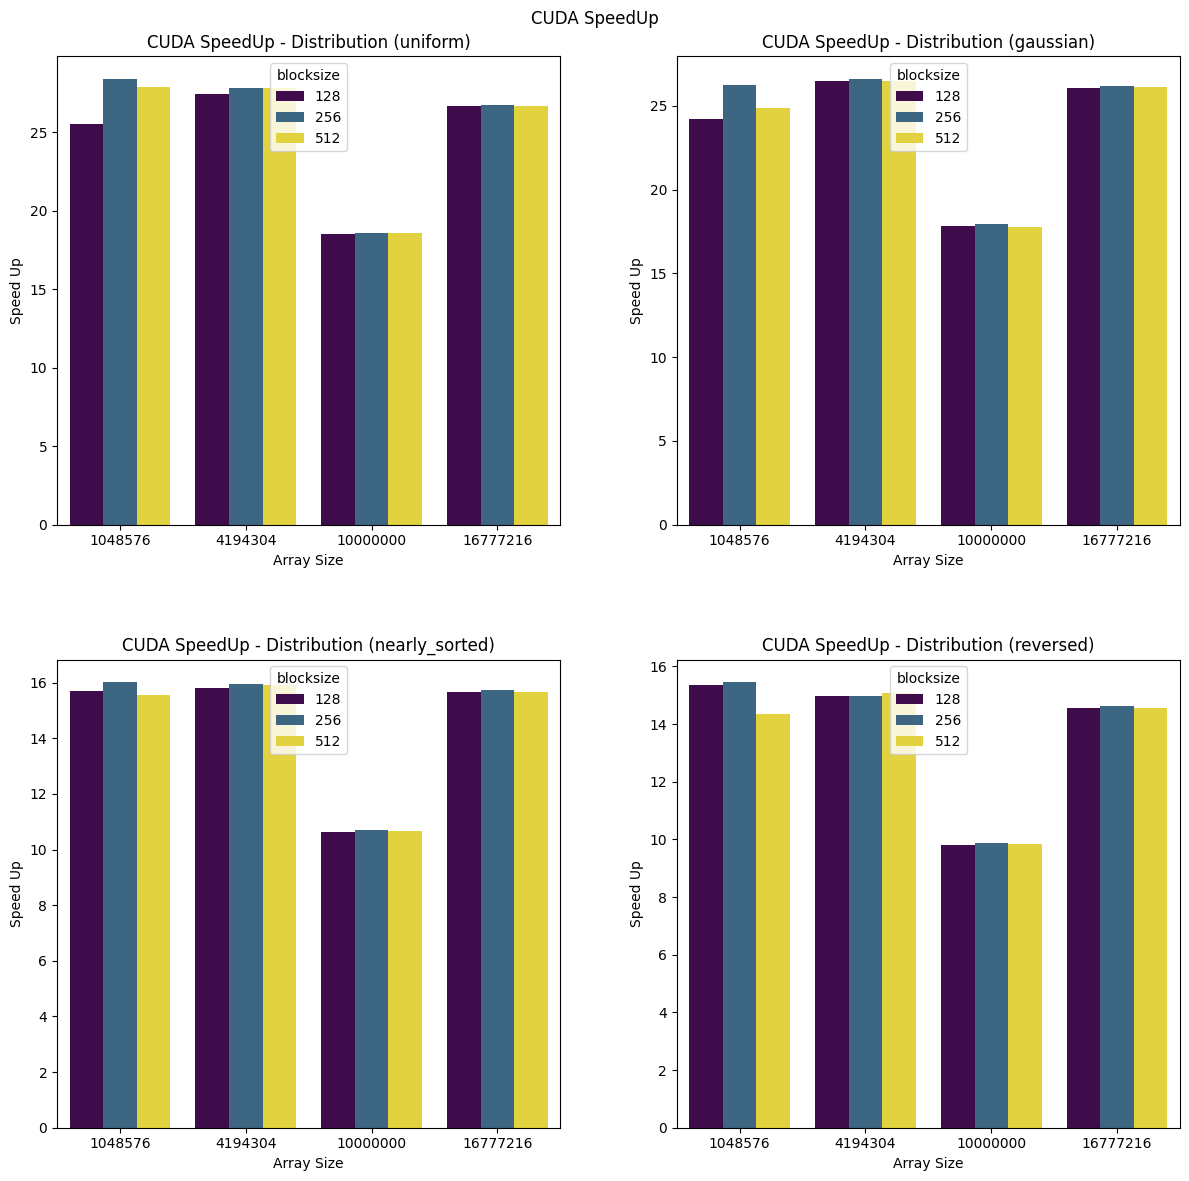

In [18]:
cuda_exp = experiments_data[experiments_data['implementation'] == 'cuda']
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 12))


dists = ["uniform", "gaussian", "nearly_sorted", "reversed"]
for ax, d in zip(axes.flat, dists):
    sns.barplot(data = cuda_exp[cuda_exp["array_distribution"] == d], x = "array_size", y = 'speedup', hue = "blocksize", ax = ax, palette = "viridis")

    ax.set_title(f'CUDA SpeedUp - Distribution ({d})')
    ax.set_ylabel('Speed Up')
    ax.set_xlabel('Array Size')

fig.suptitle('CUDA SpeedUp')
plt.tight_layout(h_pad = 5, w_pad = 5)

plt.savefig(f"results_figures/cuda_speedup.png")
plt.show()

---
---

***ALHAMDULILLAH***